# 03 · Plot fluxes and time lag used

For each analyzer (QCL, LGR) and gas (N2O, CH4), a combined figure shows three
rows with the five scenarios ([processing versions](../docs/processing-versions.md))
as columns: the flux on top, the time lag used over time in the middle, and a
histogram of that time lag on the bottom. This lines up each scenario's flux
directly above the lag that produced it and its distribution.

Scenarios `*-1` to `*-4` read their flux from the column subsets
(`data/02-…_subsets/`); their lag rows use the EddyPro time lag used
(`*_TLAG_USED`). The constant-lag scenario (`*-4`) has a single lag value, so its
bottom panel is a short note giving that constant value (read from the data)
rather than a histogram.

The fifth column is the PWB scenario (`*-5`). Its flux also comes from the column
subsets, but its lag rows use the detected PWB lag
(`*_tlag_final_pf_s`, from `data/01-pwb_tlag_summary_parquet/`): for PWB the lag
was removed from the raw data before flux processing, so the EddyPro `*_TLAG_USED`
columns carry no compensation and the detected lag is what actually shaped the
flux. The histogram count axis is shared across columns, scaled to the tallest
peak across all scenarios.

Four figures are saved: `figures/03_{qcl,lgr}_{n2o,ch4}.png`. These are
intermediate figures (small size / low DPI); bump `FIGSIZE` / `DPI` for
publication-ready output.

## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

from diive.core.io.files import load_parquet

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

In [2]:
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")  # flux scenarios
PWBDIR = Path("../data/01-pwb_tlag_summary_parquet")                  # PWB (*-5) tlag
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# Figure size / resolution. Kept small here — these are intermediate figures.
# Widened to 16 inches to fit five columns; tall enough for three rows
# (flux, lag over time, lag histogram). Increase for publication output.
FIGSIZE = (16, 9)
DPI = 300

# Analysis year. The flux subsets are already restricted to this year in
# notebook 02; the PWB tlag is filtered to it here so all panels match.
YEAR = 2021

# One figure per analyzer x gas. Columns = the four flux scenarios (*-1 to *-4)
# plus the PWB scenario (*-5) as the last column. All five scenarios have flux;
# the *-5 column's lag rows use its detected PWB lag (the *_TLAG_USED columns
# carry no compensation for PWB, since the lag was removed from the raw data).
ANALYZERS = {
    "QCL": {"flux_variants": ["QCL-1", "QCL-2", "QCL-3", "QCL-4"], "pwb": "QCL-5"},
    "LGR": {"flux_variants": ["LGR-1", "LGR-2", "LGR-3", "LGR-4"], "pwb": "LGR-5"},
}
# Per gas: the flux variable (top row), the time-lag-used variable (middle/bottom
# rows of the flux scenarios), and the PWB final applied-lag column (PWB column).
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED", "pwb_lag": "n2o_tlag_final_pf_s"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED", "pwb_lag": "ch4_tlag_final_pf_s"},
}
# Row colors: flux (teal, ColorBrewer Dark2), lag over time (orange, Dark2),
# lag histogram (modern indigo).
FLUX_COLOR = "#1b9e77"  # teal
LAG_COLOR = "#d95f02"   # orange
HIST_COLOR = "#6c5ce7"  # indigo

# Lag histogram bin width, in seconds (the EddyPro tlag grid is 0.05 s).
BIN_S = 0.05

# Robust flux y-range: clip the flux axis to this percentile range (per figure)
# so outliers don't flatten the signal. The lag axis is left to autoscale.
PCTL = (1, 99)

# Load each flux scenario's subset (*-1 to *-4) and the PWB flux subset (*-5),
# plus the PWB tlag summaries, restricted to YEAR. The PWB flux subset is loaded
# if present; the `has_flux` guard below keeps the figure working if it is not.
flux_codes = [c for a in ANALYZERS.values() for c in a["flux_variants"]]
data = {c: load_parquet(filepath=str(SUBSETDIR / f"{c}.parquet")) for c in flux_codes}
for a in ANALYZERS.values():
    pwb_flux = SUBSETDIR / f"{a['pwb']}.parquet"
    if pwb_flux.exists():
        data[a["pwb"]] = load_parquet(filepath=str(pwb_flux))
pwb_data = {
    a["pwb"]: load_parquet(filepath=str(PWBDIR / f"{a['pwb']}_pwb_tlag.parquet"))
    for a in ANALYZERS.values()
}
data = {c: d.loc[d.index.year == YEAR] for c, d in data.items()}
pwb_data = {c: d.loc[d.index.year == YEAR] for c, d in pwb_data.items()}

for c, df in {**data, **pwb_data}.items():
    print(f"{c}: {df.shape[0]} rows x {df.shape[1]} cols")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.183 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-2.parquet (0.018 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-3.parquet (0.004 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-4.parquet (0.002 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-1.parquet (0.022 seconds).

...

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-5.parquet (0.002 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-5.parquet (0.003 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\QCL-5_pwb_tlag.parquet (0.097 seconds).

> Loaded .parquet file ..\data\01-pwb_tlag_summary_parquet\LGR-5_pwb_tlag.parquet (0.006 seconds).

QCL-1: 9632 rows x 5 cols
QCL-2: 9632 rows x 5 cols
QCL-3: 9632 rows x 5 cols
QCL-4: 9632 rows x 5 cols
LGR-1: 7803 rows x 5 cols
LGR-2: 7803 rows x 5 cols
LGR-3: 7803 rows x 5 cols
LGR-4: 7803 rows x 5 cols
QCL-5: 9711 rows x 62 cols
LGR-5: 7803 rows x 62 cols


## Figures

One figure per analyzer x gas: flux (top) over time lag used (bottom), variants
as columns.

Saved ..\figures\03_qcl_n2o.png


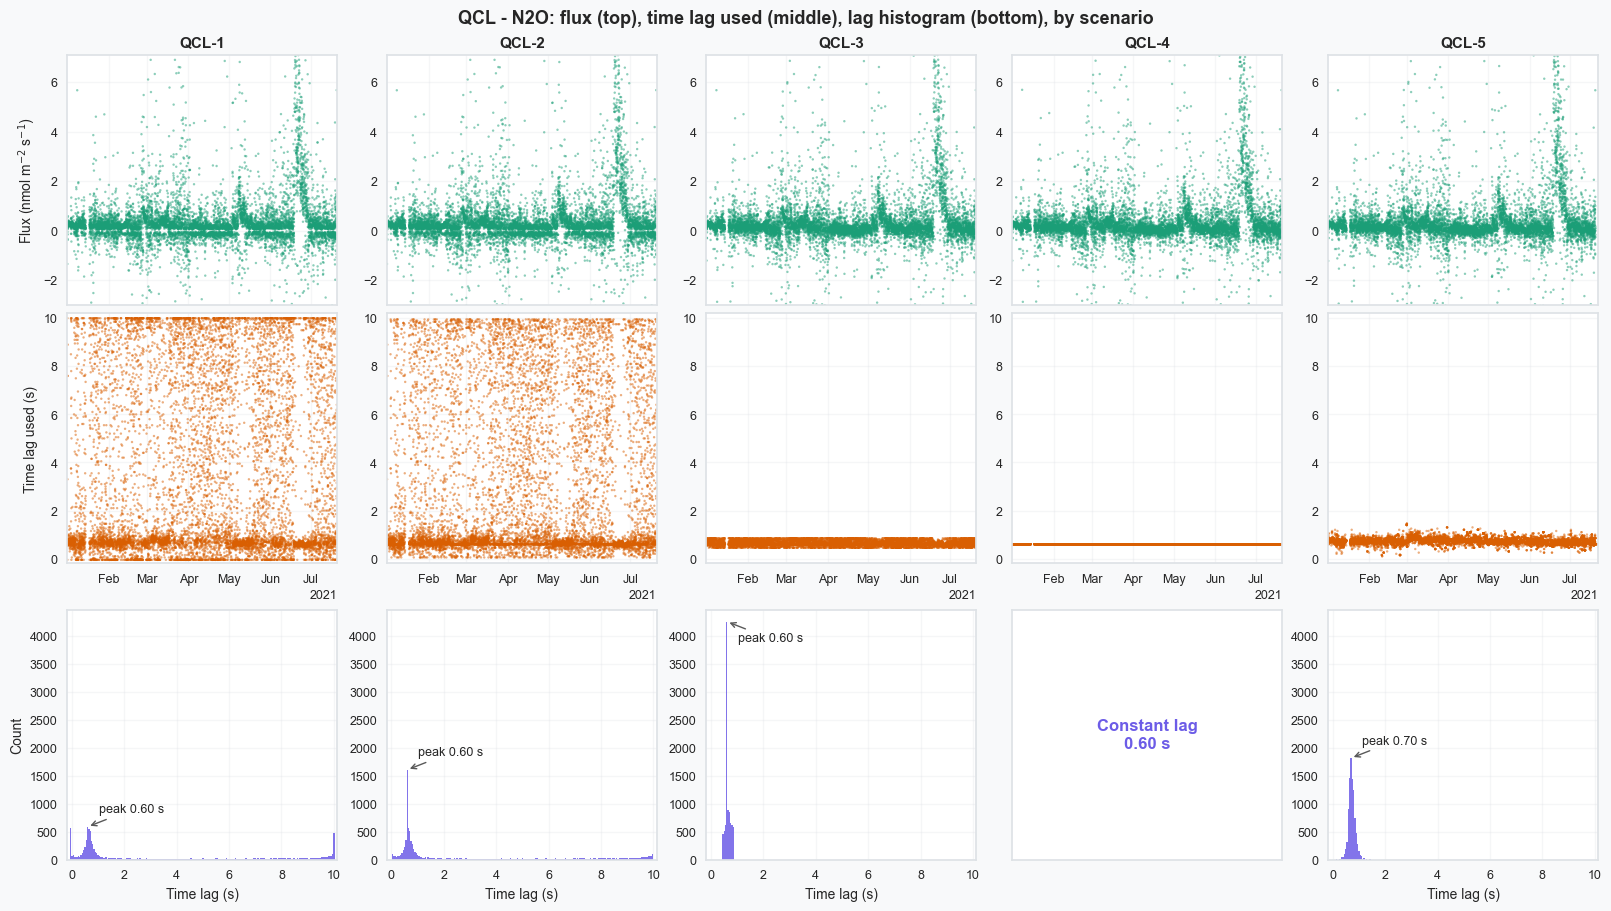

Saved ..\figures\03_qcl_ch4.png


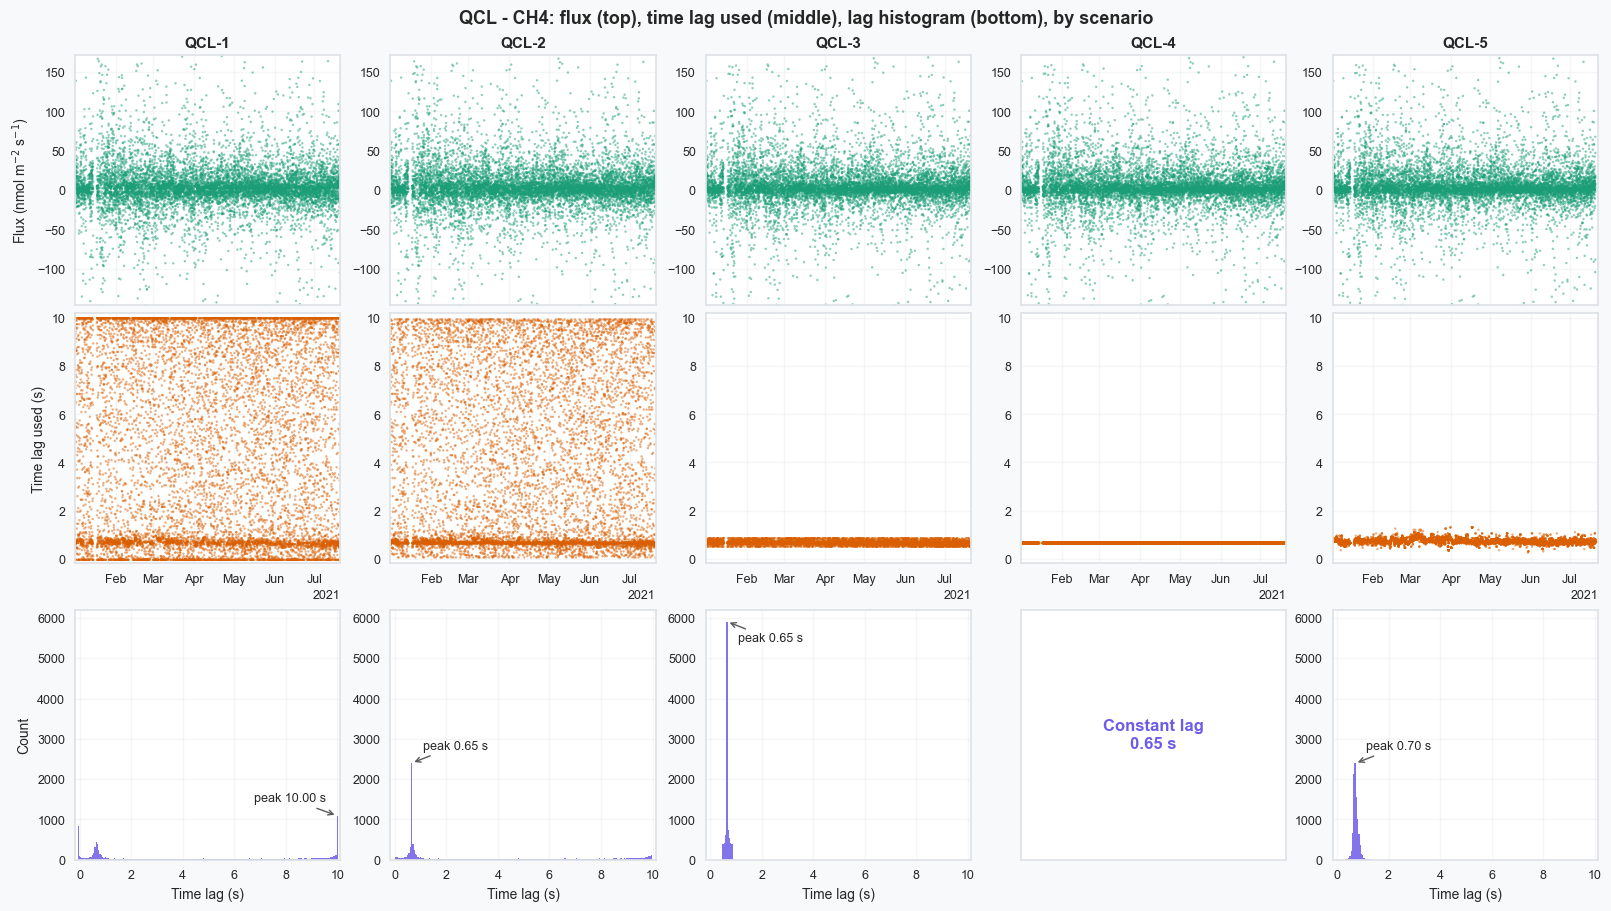

Saved ..\figures\03_lgr_n2o.png


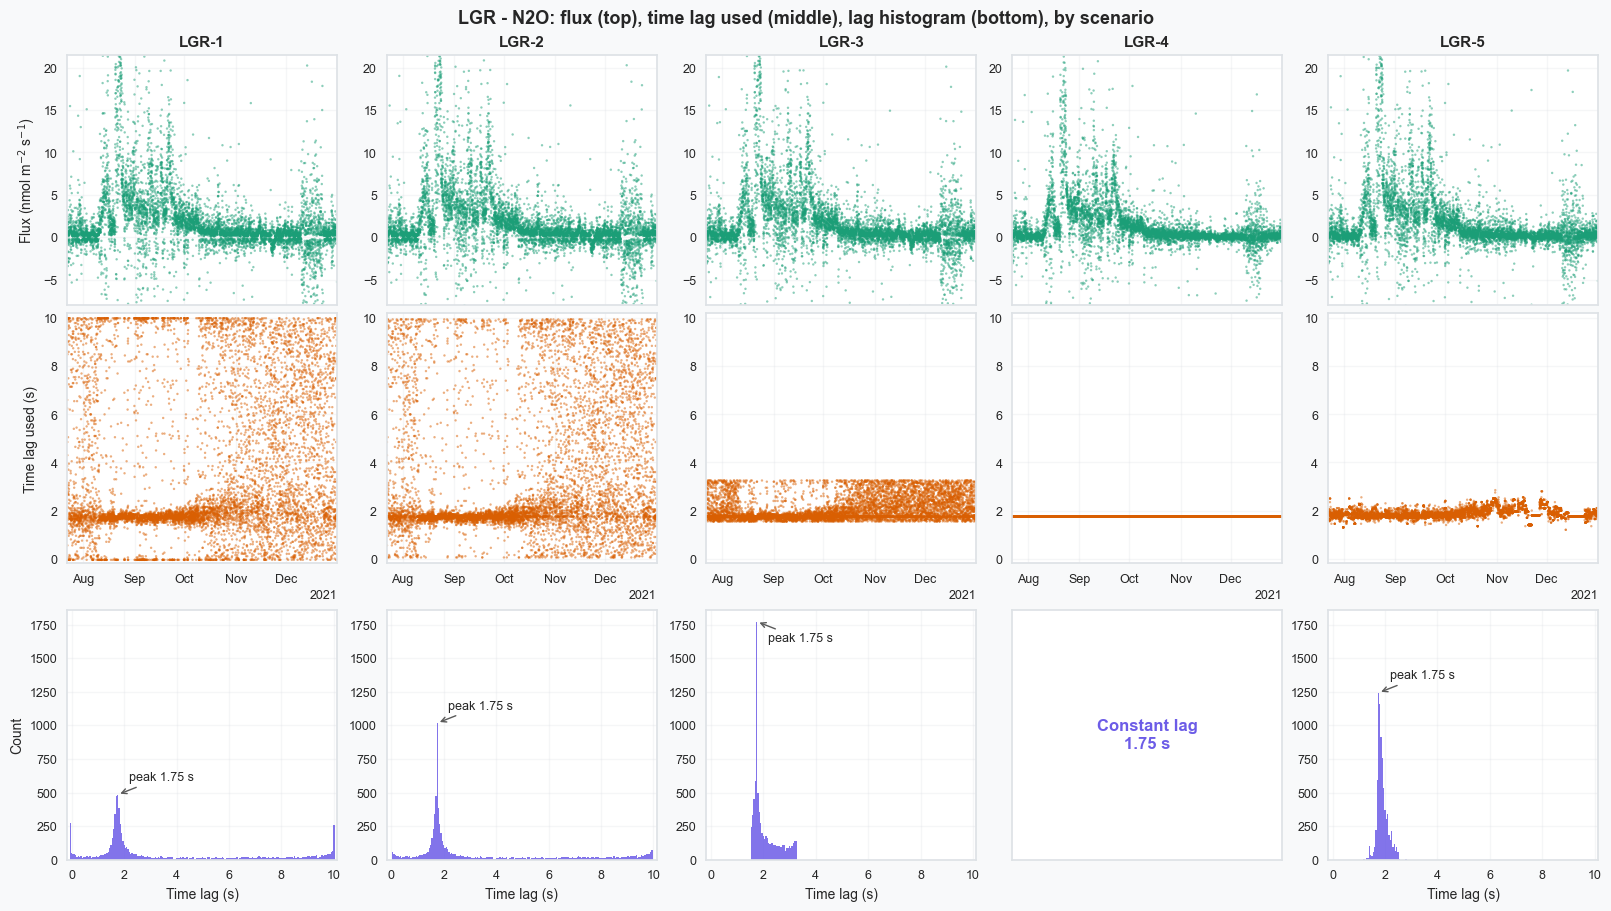

Saved ..\figures\03_lgr_ch4.png


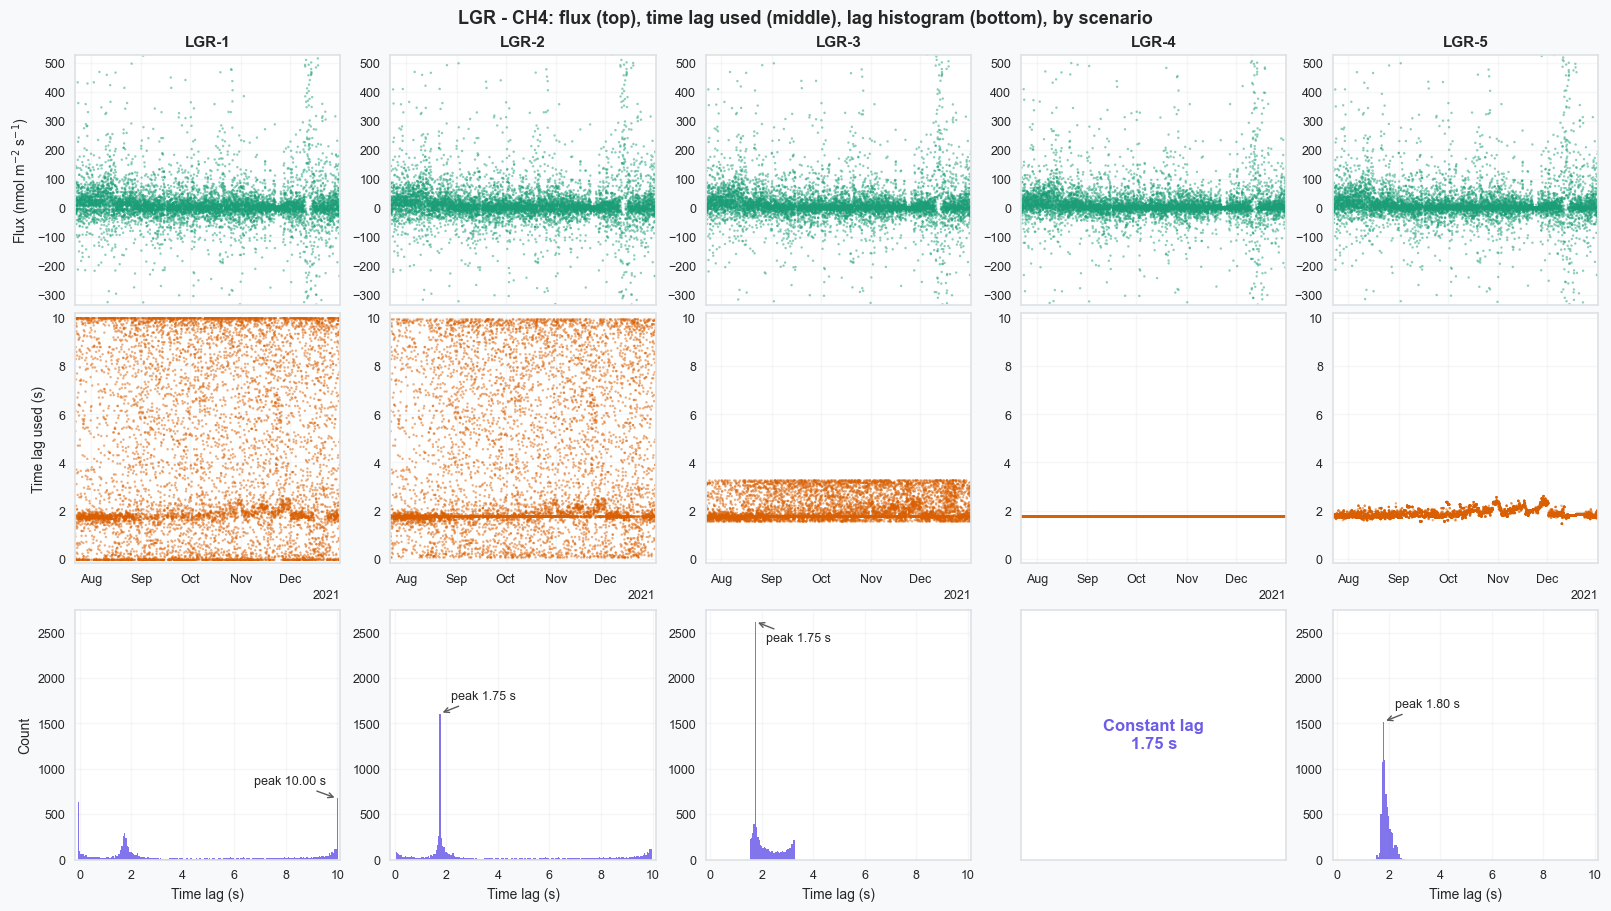

In [3]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


# Fixed y-range for the lag-over-time panels (row 2): the full 0 to 10 s search
# window with a small pad on each side.
LAG_YLIM = (-0.2, 10.2)

for analyzer, info in ANALYZERS.items():
    flux_variants = info["flux_variants"]
    pwb_code = info["pwb"]
    columns = flux_variants + [pwb_code]  # PWB is the last column

    for gas, v in GASES.items():
        fluxvar, lagvar, pwb_lag = v["flux"], v["lag"], v["pwb_lag"]

        # The lag series shown for each column: PWB uses its detected lag, the
        # others use the EddyPro time lag used.
        def lag_of(code):
            return pwb_data[code][pwb_lag] if code == pwb_code else data[code][lagvar]

        # Robust flux range across the columns that have flux (normally all five;
        # the `in data` guard tolerates a missing PWB flux subset).
        flux_cols = [c for c in columns if c in data]
        flux_vals = np.concatenate([data[c][fluxvar].to_numpy().ravel() for c in flux_cols])
        flux_ylim = robust_ylim(flux_vals)

        # Common lag range across all columns, used to build the histogram bins.
        all_lag = np.concatenate([lag_of(c).to_numpy().ravel() for c in columns])
        lag_lo, lag_hi = np.nanmin(all_lag), np.nanmax(all_lag)

        # Histogram bins of width BIN_S (0.05 s). All lags (the EddyPro time lag
        # used AND the PWB detected lag) lie on the 0.05 s grid, so the bins are
        # centered on that grid: each bar then represents exactly one grid value,
        # its center reads as a clean lag for the peak label, and float jitter
        # near a value (1.80 stored as 1.79999...) stays within one bin instead
        # of splitting across two (which would undercount the bar and misplace
        # the annotated peak).
        lo_k = int(np.floor(lag_lo / BIN_S))
        hi_k = int(np.ceil(lag_hi / BIN_S))
        bins = (np.arange(lo_k, hi_k + 2) - 0.5) * BIN_S

        # Histogram count axis scaled to the tallest peak across all scenarios
        # that show a histogram (every column except the constant-lag *-4 note),
        # so the busiest distribution fills the panel and all columns share one
        # count scale.
        hist_codes = [c for c in columns if not c.endswith("-4")]
        peak_count = max(
            int(np.histogram(lag_of(c).dropna(), bins=bins)[0].max()) for c in hist_codes
        )
        hist_ylim = (0, peak_count * 1.05)
        hist_xlim = (bins[0] - 0.1, bins[-1] + 0.1)

        fig, axes = plt.subplots(
            nrows=3, ncols=len(columns),
            figsize=FIGSIZE,
            constrained_layout=True,
        )

        for ci, code in enumerate(columns):
            ax_flux, ax_lag, ax_hist = axes[0, ci], axes[1, ci], axes[2, ci]
            has_flux = code in data

            # Flux and its lag-over-time panel share the time axis. Flux panels
            # share one y-scale; lag-scatter panels share another.
            ax_lag.sharex(ax_flux)
            if ci > 0:
                ax_flux.sharey(axes[0, 0])
                ax_lag.sharey(axes[1, 0])

            for ax in (ax_flux, ax_lag, ax_hist):
                ax.grid(True, alpha=0.3)
            ax_flux.set_title(code, fontweight="bold")

            # Row 1: flux over time. All scenarios normally have flux; the guard
            # falls back to a placeholder only if a flux subset is missing.
            if has_flux:
                df = data[code]
                ax_flux.scatter(df.index, df[fluxvar], s=3, alpha=0.5,
                                color=FLUX_COLOR, edgecolors="none")
            else:
                ax_flux.text(0.5, 0.5, "Flux pending", ha="center", va="center",
                             transform=ax_flux.transAxes, fontsize=11,
                             color="0.5", style="italic")
            ax_flux.set_ylim(flux_ylim)
            ax_flux.tick_params(labelbottom=False)  # time axis is labelled on row 2

            # Row 2: time lag over time.
            lag = lag_of(code)
            ax_lag.scatter(lag.index, lag, s=3, alpha=0.5,
                           color=LAG_COLOR, edgecolors="none")
            ax_lag.set_ylim(*LAG_YLIM)
            loc = mdates.AutoDateLocator()
            ax_lag.xaxis.set_major_locator(loc)
            ax_lag.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

            # Clip the shared time axis exactly to the data's start and end (no
            # autoscale padding). The flux and lag indexes can differ, so take
            # the combined range of what exists.
            idxs = [lag.index] + ([data[code].index] if has_flux else [])
            ax_lag.set_xlim(min(i.min() for i in idxs), max(i.max() for i in idxs))

            # Row 3: histogram of the time lag, on the shared count axis. The
            # constant-lag (*-4) scenario has a single lag value, so instead of a
            # one-bar histogram it shows a note with that value (read from the data).
            if code.endswith("-4"):
                const = lag.dropna().mode()
                const = const.iloc[0] if not const.empty else float("nan")
                ax_hist.text(0.5, 0.5, f"Constant lag\n{const:.2f} s",
                             ha="center", va="center", transform=ax_hist.transAxes,
                             fontsize=12, fontweight="bold", color=HIST_COLOR)
                ax_hist.set_xticks([])
                ax_hist.set_yticks([])
            else:
                counts, edges = np.histogram(lag.dropna(), bins=bins)
                ax_hist.hist(lag.dropna(), bins=bins, color=HIST_COLOR, alpha=0.85)
                # Extend the x-axis 0.1 s beyond the bin grid on each side so the
                # edge bins are not flush against the panel border.
                ax_hist.set_xlim(*hist_xlim)
                ax_hist.set_ylim(hist_ylim)
                ax_hist.set_xlabel("Time lag (s)")

                # Annotate the tallest drawn bar: take the busiest histogram bin
                # and point at its top. peak_x is the bin center, i.e. the 0.05 s
                # grid value the bar represents.
                imax = int(counts.argmax())
                peak_x = 0.5 * (edges[imax] + edges[imax + 1])
                peak_y = int(counts[imax])
                # Offset the label toward the inside of the panel so it never
                # spills past an edge: flip to the left when the peak sits in the
                # right part of the lag range, and below when it nears the top.
                near_right = peak_x > hist_xlim[0] + 0.7 * (hist_xlim[1] - hist_xlim[0])
                near_top = peak_y > 0.85 * hist_ylim[1]
                dx, ha = (-8, "right") if near_right else (8, "left")
                dy, va = (-8, "top") if near_top else (8, "bottom")
                ax_hist.annotate(f"peak {peak_x:.2f} s",
                                 xy=(peak_x, peak_y), xytext=(dx, dy),
                                 textcoords="offset points", ha=ha, va=va,
                                 fontsize=9, color="0.15",
                                 arrowprops=dict(arrowstyle="->", color="0.35", lw=1))

        axes[0, 0].set_ylabel("Flux (nmol m$^{-2}$ s$^{-1}$)")
        axes[1, 0].set_ylabel("Time lag used (s)")
        axes[2, 0].set_ylabel("Count")
        fig.suptitle(f"{analyzer} - {gas}: flux (top), time lag used (middle), "
                     f"lag histogram (bottom), by scenario",
                     fontsize=13, fontweight="bold")

        out = FIGDIR / f"03_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Runtime

In [4]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-23 10:14:58
End:      2026-06-23 10:15:12
Runtime:  0:00:14.237526
